# Relaxing a spin spiral: `dE/dq`

The spiral wavevector is a coordinate of the calculation exactly as an atomic position is, so
it gets the same treatment: the total energy as a function of $\mathbf q$ at **frozen**
wavefunctions, its gradient, and a walk downhill.

$$\frac{dE}{d\mathbf q} = \left.
   \frac{\partial E_{\rm tot}[\{u\}, \mathbf q]}{\partial \mathbf q}
   \right|_{\{u\}\ \rm fixed},
\qquad
\mathbf q^{\,\rm new} = \mathbf q - s\,H^{-1}\frac{dE}{d\mathbf q}$$

with BFGS run on the **reciprocal** metric $\mathbf b_i\cdot\mathbf b_j$, since that is the
space $\mathbf q$ lives in. Freezing the states is legitimate for the same reason it is for a
force: the energy is stationary in them. The derivative is taken of the total energy itself
rather than derived by hand for the purpose.

| | |
|---|---|
| a hydrogen chain started at $q_3 = 0.30$ finds | **$q_3 = 0.500014$** |
| in | **6 self-consistent runs** |
| where notebook 12's scan of the same curve needs | 11 |

The physical content is the **pitch of the magnetic order itself**, which for an
incommensurate helimagnet is not a number any supercell calculation can produce. `pw.x` has
no spiral, so the validation is finite differences and symmetry.

In [1]:
from pathlib import Path

from pypresso import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")
CHAIN = (CASES / "h-chain-spiral.in").read_text().replace("ecutwfc = 25.0",
                                                          "ecutwfc = 40.0")

def chain_at(q3):
    return Calculator.from_text(CHAIN.replace("spiral_q(3) = 0.25",
                                              "spiral_q(3) = %s" % q3), PSEUDO,
                                announce=False, max_iterations=300)

relaxed = chain_at(0.30).get_spiral_relaxation(free=(0, 0, 1), nstep=20)
print("q3 = %.6f   in %d self-consistent runs"
      % (relaxed.wavevector[2], relaxed.nsteps))

q3 = 0.500014   in 6 self-consistent runs


The cutoff is raised from the input's 25 Ry to 40 for this notebook, and the reason is the
one thing a moving $\mathbf q$ costs that a moving *atom* does not. The set of plane waves
inside the cutoff **changes** as $\mathbf q$ moves, because the two spinor components sit on
spheres centred at $\mathbf k \pm \mathbf q/2$; so `E(q)` jumps very slightly whenever a
plane wave crosses in or out. That is the ordinary Pulay error of a finite basis, and it is
erratic rather than smoothly convergent, because it counts crossings rather than truncating a
series: measured offline against a sphere-rebuilding finite difference, **8.3e-4 Ry per unit
`q` at `ecutwfc = 25`, 5.8e-4 at 40 and 8.3e-6 at 60**.

The step-by-step path, with the gradient it is chasing:

In [2]:
import matplotlib.pyplot as plt
import numpy as np

print("%5s %10s %18s %14s %9s"
      % ("step", "q3", "E [Ry]", "max |dE/dq|", "SCF its"))
for step in relaxed.steps:
    print("%5d %10.5f %18.10f %14.2e %9d"
          % (step.index, step.wavevector[2], step.total_energy, step.max_gradient,
             step.scf_iterations))
print("\nconverged = %s;  the answer it had to find is q3 = 0.5, and it was not told"
      % relaxed.converged)

 step         q3             E [Ry]    max |dE/dq|   SCF its
    1    0.30000      -0.9620589567       5.03e-03        11
    2    0.34463      -0.9625849405       4.76e-03         8
    3    0.39372      -0.9630968974       3.77e-03         8
    4    0.46736      -0.9635797035       1.29e-03         8
    5    0.50559      -0.9636329038       2.20e-04         8
    6    0.50001      -0.9636298167       5.77e-07         7

converged = True;  the answer it had to find is q3 = 0.5, and it was not told


**The last two steps disagree by 3e-6 Ry and the later one is higher.** That is not a failed
line search: it is the Pulay error quoted above, 5.8e-4 Ry per unit `q` at this cutoff, over
the 0.0056 the step moved. The surface is flat there to within what a finite basis can
resolve, and the gradient falling to 6e-7 is the statement that matters.

**Symmetry pins two wavevectors exactly**, and not to within a tolerance. $\mathbf q$ and
$-\mathbf q$ are the same spiral mirrored, so $E(q)$ is even about $q = 0$ and about the zone
boundary $q = b_3/2$, and its slope has to vanish at both. The relaxation lands on the second
of those, and its final gradient is that statement measured rather than assumed.

Nothing told the search that the answer lies on the axis, either: the gradient is a vector,
and the two transverse components were free to move if the physics had asked them to.

## The surface, and the path across it

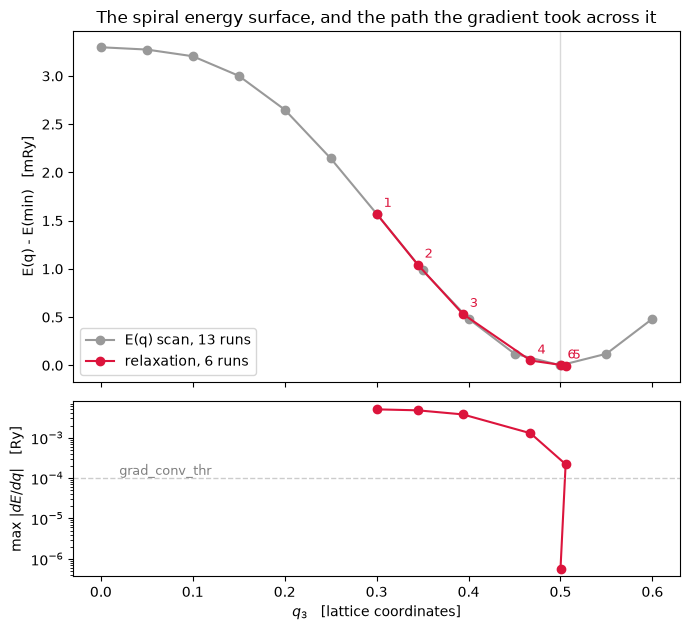

In [3]:
scan_q = np.linspace(0.0, 0.6, 13)
scan = chain_at(0.0).get_spiral_scan(
    np.column_stack([np.zeros_like(scan_q), np.zeros_like(scan_q), scan_q]))

path = np.array([[s.wavevector[2], s.total_energy] for s in relaxed.steps])
floor = scan.energies.min()

fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.0, 6.4), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})
top.plot(scan_q, 1e3 * (scan.energies - floor), "o-", color="0.6",
         label="E(q) scan, %d runs" % len(scan_q))
top.plot(path[:, 0], 1e3 * (path[:, 1] - floor), "o-", color="crimson",
         label="relaxation, %d runs" % relaxed.nsteps)
for index, (q3, energy) in enumerate(path, start=1):
    top.annotate(str(index), (q3, 1e3 * (energy - floor)), textcoords="offset points",
                 xytext=(5, 5), color="crimson", fontsize=9)
top.axvline(0.5, color="0.85", lw=1.0, zorder=0)
top.set(ylabel="E(q) - E(min)   [mRy]",
        title="The spiral energy surface, and the path the gradient took across it")
top.legend()

bottom.plot(path[:, 0], [s.max_gradient for s in relaxed.steps], "o-", color="crimson")
bottom.axhline(1e-4, color="0.8", lw=1.0, ls="--")
bottom.set(yscale="log", xlabel="$q_3$   [lattice coordinates]",
           ylabel=r"max $|dE/dq|$   [Ry]")
bottom.annotate("grad_conv_thr", (0.02, 1.2e-4), color="0.5", fontsize=9)
fig.tight_layout()

The relaxation reaches the minimum in a fraction of the runs the scan needs, and the scan is
drawn here only to show what it was walking on -- a real use of this would never compute it.

**One trap is worth knowing about, and it is BFGS's rather than the spiral's.** The initial
inverse Hessian that works for atoms assumes a chemical bond, about 1 Ry/bohr²; a magnetic
energy surface is milli-Rydbergs deep, two orders softer, so the first step of an unmodified
BFGS overshoots the zone. `BFGSSettings.hessian_scale` sets that first step to the trust
radius instead.

## What it refuses

A **magnetic field**, because its energy is deliberately left out of the reported total
(notebook 11) -- so the state would be stationary for a different functional than the one
being differentiated, and the gradient would be of neither. Everything notebook 12 refuses
applies here too: spin-orbit coupling permanently, symmetry until the spin space group
exists, and ultrasoft or PAW datasets.

---
The tests behind this notebook: `tests/regression/test_spiral_relaxation.py`, which holds the
identity that the functional being differentiated *is* the total energy at the converged
state, the gradient against a finite difference of that functional at frozen states, the
sharper one against re-converged runs at moved $\mathbf q$, and the exact vanishing of the
gradient at the two symmetry points.